In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import catboost as cb
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")


In [7]:
df=pd.read_csv("data//airpollution_cleaned.csv")

In [8]:
df

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good
...,...,...,...,...,...,...,...,...,...,...
4964,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765,Hazardous
4965,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709,Moderate
4966,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379,Moderate
4967,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241,Good


In [9]:
df.shape

(4969, 10)

In [11]:
X=df.drop(columns=["Air Quality"])


In [12]:
X

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303
...,...,...,...,...,...,...,...,...,...
4964,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765
4965,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709
4966,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379
4967,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241


In [13]:
y=df[["Air Quality"]]

In [14]:
y

,Air Quality
0,Moderate
1,Moderate
2,Moderate
3,Good
4,Good
...,...
4964,Hazardous
4965,Moderate
4966,Moderate
4967,Good


In [15]:
numeric_cols=X.select_dtypes(include=np.number).columns.tolist()

In [16]:
numeric_cols

['Temperature',
 'Humidity',
 'PM2.5',
 'PM10',
 'NO2',
 'SO2',
 'CO',
 'Proximity_to_Industrial_Areas',
 'Population_Density']

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
numeric_transformer=StandardScaler()
preprocessor=ColumnTransformer(
    [
        ("standardScaler",numeric_transformer,numeric_cols),
    ]
)

In [18]:
X=preprocessor.fit_transform(X)

In [19]:
X

array([[-0.03472948, -0.68954955, -0.60845496, ...,  0.40070315,
        -0.58708133, -1.1678008 ],
       [-0.25770835,  0.34972597, -0.72650868, ...,  0.2542386 ,
        -0.6702424 ,  0.74174064],
       [-1.03070178,  0.29303821,  0.26677088, ...,  0.23593054,
        -0.89200525,  0.79405685],
       ...,
       [-0.61447455,  0.5134906 , -0.24208135, ...,  0.23593054,
         0.32769042, -0.77542927],
       [-0.7036661 , -1.61544955,  0.05101753, ..., -1.11886651,
         0.88209755, -1.67788378],
       [-0.88204919,  0.49459468,  2.50572069, ..., -0.22177117,
        -0.03267421, -0.23918818]], shape=(4969, 9))

In [20]:
y

,Air Quality
0,Moderate
1,Moderate
2,Moderate
3,Good
4,Good
...,...
4964,Hazardous
4965,Moderate
4966,Moderate
4967,Good


In [21]:
# Apply LabelEncoder to target column
label_encoder = LabelEncoder()
y= label_encoder.fit_transform(y)


# Correct mapping: category name → encoded value
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", label_mapping)




Label Mapping: {'Good': np.int64(0), 'Hazardous': np.int64(1), 'Moderate': np.int64(2), 'Poor': np.int64(3)}


In [22]:
y

array([2, 2, 2, ..., 2, 0, 2], shape=(4969,))

# Train_Test_split

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=10)

In [24]:
def evaluate_classification(true, predicted):
    accuracy = accuracy_score(true, predicted)
    precision = precision_score(true, predicted, average="weighted")
    recall = recall_score(true, predicted, average="weighted")
    f1 = f1_score(true, predicted, average="weighted")
    
    return accuracy, precision, recall, f1


In [25]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=500),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "NaiveBayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="mlogloss"),
    "CatBoost": cb.CatBoostClassifier(verbose=0)
}
model_list = []
acc_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc, prec, rec, f1 = evaluate_classification(y_test, y_pred)
    
    print(f"🔹 {name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("="*40)
    
    model_list.append(name)
    acc_list.append(acc)

🔹 LogisticRegression
Accuracy: 0.9342723004694836
Precision: 0.93391222715675
Recall: 0.9342723004694836
F1 Score: 0.9339358374990161
Confusion Matrix:
 [[571   0   1   0]
 [  0 135   0  28]
 [  5   0 426  19]
 [  0  16  29 261]]
🔹 KNN
Accuracy: 0.9248826291079812
Precision: 0.9243444110630952
Recall: 0.9248826291079812
F1 Score: 0.9235024172857147
Confusion Matrix:
 [[572   0   0   0]
 [  0 125   0  38]
 [ 11   0 431   8]
 [  0  10  45 251]]
🔹 SVC
Accuracy: 0.9369550637156271
Precision: 0.9369585011089696
Recall: 0.9369550637156271
F1 Score: 0.9365407000405358
Confusion Matrix:
 [[571   0   1   0]
 [  0 135   0  28]
 [  3   0 430  17]
 [  0  10  35 261]]
🔹 DecisionTree
Accuracy: 0.9101274312541918
Precision: 0.9096935519653344
Recall: 0.9101274312541918
F1 Score: 0.9097588378301117
Confusion Matrix:
 [[570   0   2   0]
 [  0 134   0  29]
 [  0   2 419  29]
 [  0  33  39 234]]
🔹 RandomForest
Accuracy: 0.9530516431924883
Precision: 0.9529591473677619
Recall: 0.9530516431924883
F1 Score:

# 7. Compare Results

In [26]:
results = pd.DataFrame(list(zip(model_list, acc_list)), columns=["Model", "Accuracy"])
print("\nModel Comparison:\n", results.sort_values(by="Accuracy", ascending=False))


Model Comparison:
                 Model  Accuracy
9            CatBoost  0.954393
4        RandomForest  0.953052
6    GradientBoosting  0.951710
8             XGBoost  0.947686
2                 SVC  0.936955
0  LogisticRegression  0.934272
1                 KNN  0.924883
7          NaiveBayes  0.920858
3        DecisionTree  0.910127
5            AdaBoost  0.768612


# out of all one randomforestclassifier is the best

In [27]:
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("✅ RandomForest Classifier Performance")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


✅ RandomForest Classifier Performance

Classification Report:
               precision    recall  f1-score   support

        Good       1.00      1.00      1.00       572
   Hazardous       0.93      0.87      0.90       163
    Moderate       0.95      0.97      0.96       450
        Poor       0.90      0.89      0.90       306

    accuracy                           0.96      1491
   macro avg       0.94      0.93      0.94      1491
weighted avg       0.96      0.96      0.96      1491

Confusion Matrix:
 [[572   0   0   0]
 [  0 142   1  20]
 [  1   0 438  11]
 [  0  11  22 273]]


# Plot confusion matrix

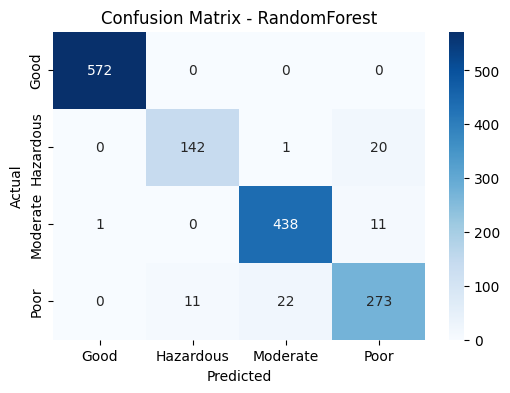

In [28]:

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - RandomForest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()